<a href="https://colab.research.google.com/github/InsightMart/DSPL_project/blob/main/RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preperation

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 6.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import category_encoders as ce
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [ ]:
# Load Dataset using pandas library
import pandas as pd
df=pd.read_csv('/content/cleaned_traincsv.csv')

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [ ]:
# Encoding categorical variables
target_encoder = ce.TargetEncoder(handle_unknown='ignore')
df['encoded_outlet_city'] = target_encoder.fit_transform(df['outlet_city'], df['cluster_catgeory'])

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,encoded_outlet_city
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,3.251460
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,3.262522
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,3.267422
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,3.267422
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,3.251460


In [ ]:
# Create a dataframe for Featuers (X) and Targets (y)
X = df[['encoded_outlet_city', 'luxury_sales', 'fresh_sales', 'dry_sales']]
y = df['cluster_catgeory']

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=4. All the features will be returned.
  warnings.warn(


<Axes: >

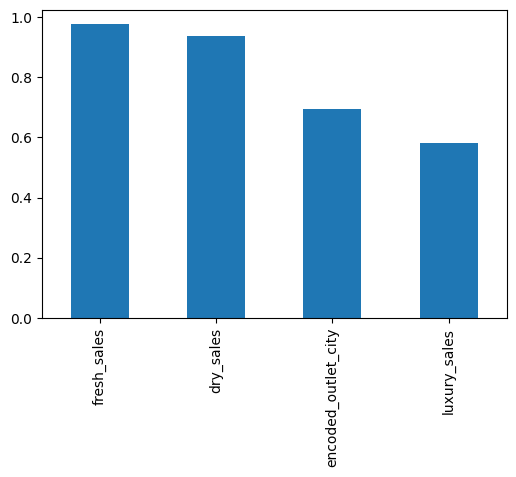

In [ ]:
# Feature importance

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(score_func=mutual_info_classif, k=10)
fs.fit(X, y)
mi_score = pd.Series(fs.scores_, index=X.columns)
mi_score.sort_values(ascending=False).plot.bar(figsize=(6, 4))

In [ ]:
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Whole Data shape', df.shape)
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

Whole Data shape (774150, 7)
X_train shape (541905, 4)
X_test shape (232245, 4)


## 9. Random Forest Model

In [ ]:
# Import the function from the package
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Perform predictions on the test data
y_pred9 = rf.predict(X_test)

In [ ]:
# Create a dataframe for comparing the actual vs predicted results by Random Forest Model
compare_results_rf_df = pd.DataFrame({'Actual cluster_catgeory' : y_test, 'Predicted cluster_catgeory': y_pred9})
compare_results_rf_df

,Actual cluster_catgeory,Predicted cluster_catgeory
201122,2,2
207061,2,2
375630,1,1
552084,1,1
24499,4,4
...,...,...
253842,2,2
615954,6,6
338522,5,5
710046,6,6


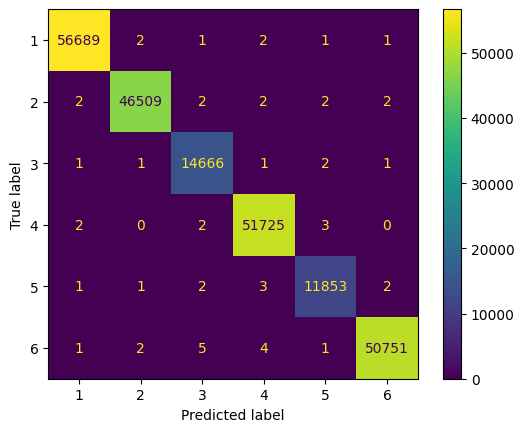

In [ ]:
# Import the packages for costructing the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Costruct the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred9, labels = rf.classes_)

# Plot the confusion matrix
disp_rf_cm = ConfusionMatrixDisplay(rf_cm, display_labels = rf.classes_)
disp_rf_cm.plot()

In [ ]:
# Classification metrics report

# Import the function from the package
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred9))

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



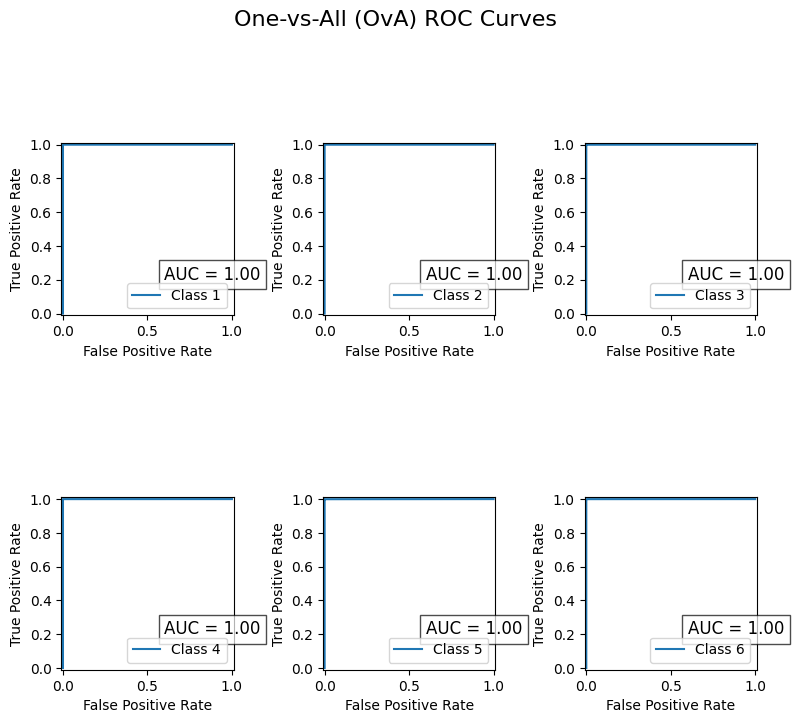

In [ ]:
# ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob9 = rf.predict_proba(X_test)

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(rf.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob9[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob9[:, i])  # Calculate AUC
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))  # Add AUC value to the plot

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to fit the suptitle
plt.show()

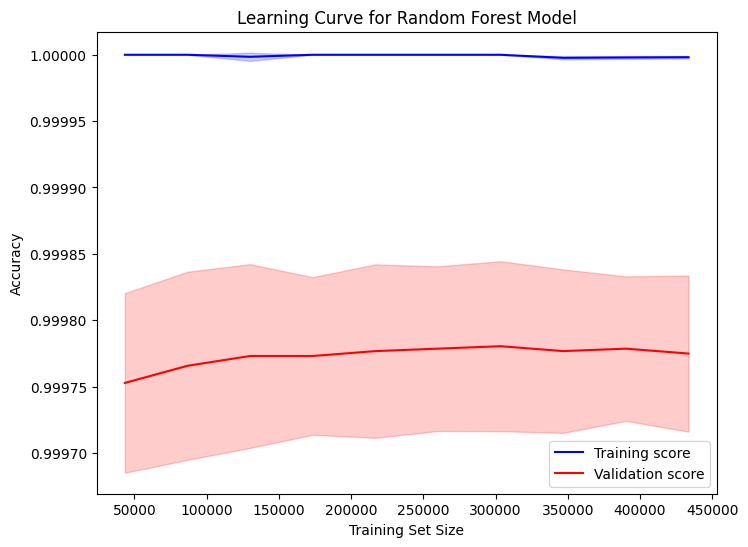

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(rf, X_train, y_train,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='accuracy', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for Random Forest Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()

## 10. Tuned Random Forest Model

In [ ]:
# Import the function from the package
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# create new a rf model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid5 = {'n_estimators': [100, 200, 300],
              'max_depth': [10, 20, None],
              'min_samples_split': [2, 5, 10],
              "min_samples_leaf": [1, 2, 4]}

#use gridsearch to test all values
rf_rscv = RandomizedSearchCV(rf, param_grid5, n_iter=10, cv=3,
                             scoring='roc_auc_ovr', n_jobs=-1, verbose=1,
                             random_state=42)
#fit model to data
rf_rscv.fit(X_train, y_train)

# Get the best estimator (tuned model)
best_rf = rf_rscv.best_estimator_
best_rf

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=5,
                       n_estimators=200, random_state=42)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



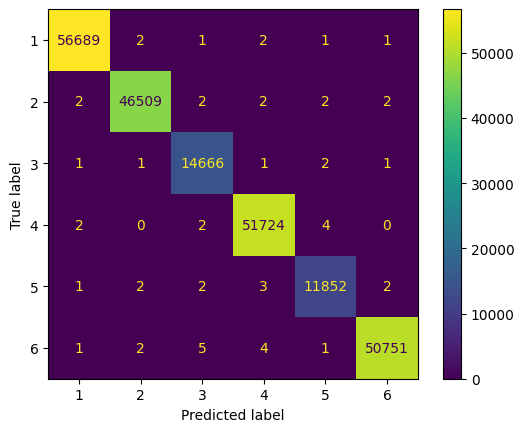

In [ ]:
# Perform testing on test dataset
y_pred10 = best_rf.predict(X_test)

# Construct a confusion matrix
cm_best_rf = confusion_matrix(y_test, y_pred10, labels = best_rf.classes_)
disp_best_rf_cm = ConfusionMatrixDisplay(cm_best_rf, display_labels=best_rf.classes_)
disp_best_rf_cm.plot()

# Display the classification report
print(classification_report(y_test, y_pred10))

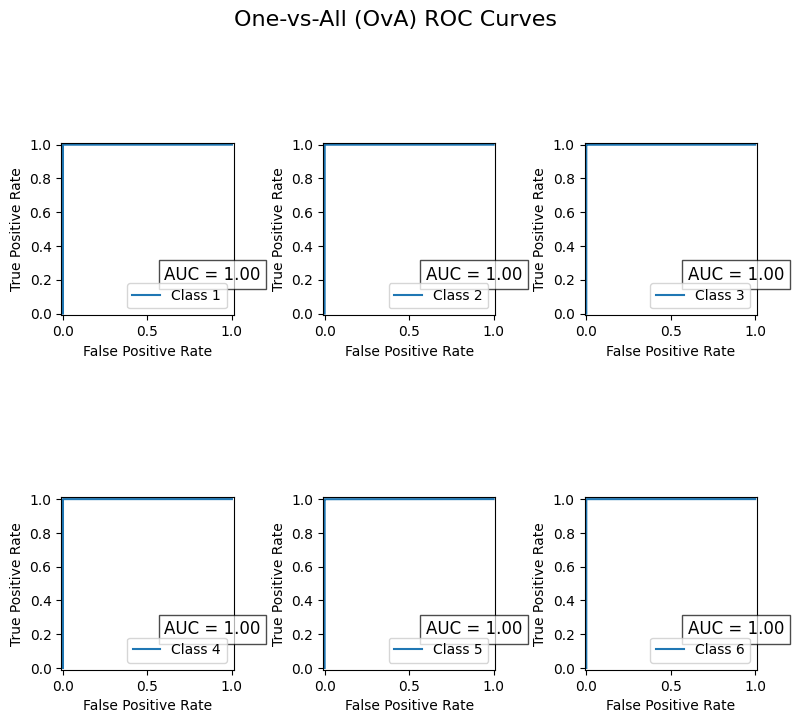

In [ ]:
# ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob10 = best_rf.predict_proba(X_test)

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(best_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob10[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob10[:, i])  # Calculate AUC
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))  # Add AUC value to the plot

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to fit the suptitle
plt.show()

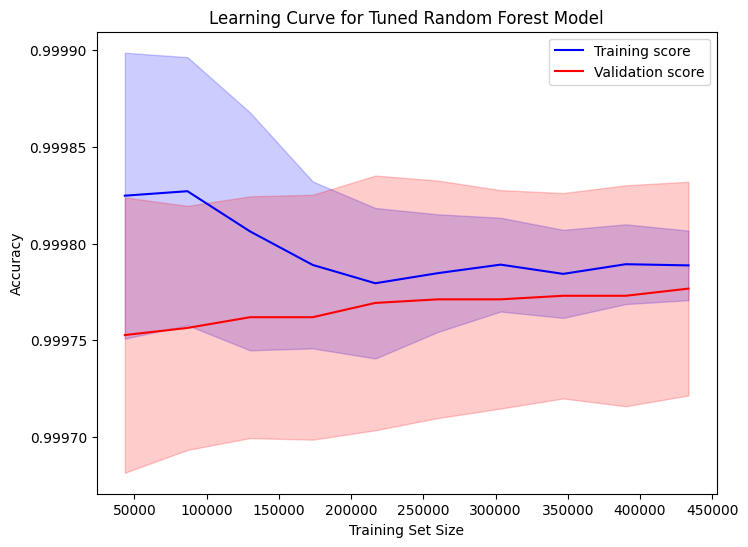

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(best_rf, X_train, y_train,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='f1_weighted', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for Tuned Random Forest Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()